# Bangkok Final 4 Rain-Any Neighbor Models

This notebook trains only the current best practical 4-model setup using precomputed features from PostgreSQL table `"OM_BKK_DATA_PRECOMPUTE"`.

Models trained:

- `1h`: LightGBM, recommended threshold `0.60`
- `2h`: LightGBM, recommended threshold `0.50`
- `3h`: HistGradientBoosting, recommended threshold `0.30`
- `6h`: HistGradientBoosting, recommended threshold `0.30`

This is the faster production-style notebook. It does not retrain baseline comparison models.

## 1. Setup

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_final_4_neighbor_models"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)
RECOMMENDED_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick smoke tests: 300_000
RANDOM_STATE = 42

## 3. Feature Columns

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 66
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load Precomputed Training Data

In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_training_data(sample_rows=None):
    select_columns = [
        "grid_number",
        "local_forecast_time AS forecast_time",
        *FEATURE_COLUMNS,
        *TARGET_COLUMNS,
    ]
    select_sql = ",\n        ".join(select_columns)
    query = f'''
    SELECT
        {select_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
    ORDER BY local_forecast_time, grid_number
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) complete_rows
        ORDER BY random()
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])

In [5]:
df = read_training_data(SAMPLE_ROWS)
print(df.shape)
print(df["forecast_time"].min(), "to", df["forecast_time"].max())
display(df.head())

required_columns = sorted(set(FEATURE_COLUMNS + TARGET_COLUMNS))
missing_counts = df[required_columns].isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

C:\Users\Brandon\AppData\Local\Temp\ipykernel_37216\187011546.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])


(2453568, 72)
2021-07-20 06:00:00 to 2026-07-19 21:00:00


,grid_number,forecast_time,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,pressure_msl_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,cloud_cover_lag_6h,humidity_lag_1h,humidity_lag_3h,humidity_lag_6h,wind_speed_lag_1h,wind_speed_lag_3h,hour_sin,hour_cos,month_sin,month_cos,grid_row,grid_column,latitude,longitude,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_cloud_cover_mean,neighbor_cloud_cover_max,neighbor_relative_humidity_mean,neighbor_relative_humidity_max,neighbor_pressure_msl_mean,neighbor_pressure_msl_min,neighbor_pressure_msl_max,neighbor_temperature_2m_mean,neighbor_dew_point_2m_mean,neighbor_temperature_dew_point_spread_mean,neighbor_wind_speed_10m_mean,neighbor_wind_speed_10m_max,row_minus_precipitation_mean,row_plus_precipitation_mean,column_minus_precipitation_mean,column_plus_precipitation_mean,row_minus_cloud_cover_mean,row_plus_cloud_cover_mean,column_minus_cloud_cover_mean,column_plus_cloud_cover_mean,neighbor_precipitation_mean_minus_center,neighbor_cloud_cover_mean_minus_center,neighbor_relative_humidity_mean_minus_center,center_pressure_msl_minus_neighbor_mean,rain_any_next_1h,rain_any_next_2h,rain_any_next_3h,rain_any_next_6h
0,1,2021-07-20 06:00:00,26.4000,87.0000,1005.6000,1005.4000,24.0000,2.4000,100.0000,18.0000,217.0000,2.4000,-0.3000,-1.8000,1.7000,1.0000,0.6000,0.3000,5.1000,6.2000,6.5000,6.5000,99.0000,99.0000,99.0000,87.0000,87.0000,87.0000,19.7000,19.9000,1.0000,0.0000,-0.5000,-0.8660,1,1,13.4940,100.3270,3.0000,2.2667,2.5000,6.8000,3.0000,1.0000,100.0000,100.0000,88.0000,90.0000,1005.6333,1005.6000,1005.7000,26.1667,23.9333,2.2333,15.8667,19.2000,0.0000,2.4000,0.0000,2.1500,100.0000,100.0000,100.0000,100.0000,-0.1333,0.0000,1.0000,-0.0333,1,1,1,1
1,2,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,2,13.4940,100.4102,5.0000,2.2800,2.5000,11.4000,5.0000,1.0000,100.0000,100.0000,87.8000,90.0000,1005.6400,1005.6000,1005.7000,26.2200,23.9800,2.2400,16.4400,19.2000,0.0000,2.3333,2.4500,2.1000,100.0000,100.0000,100.0000,100.0000,0.2800,0.0000,2.8000,0.0600,1,1,1,1
2,3,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,3,13.4940,100.4934,5.0000,1.9400,2.3000,9.7000,5.0000,1.0000,100.0000,100.0000,86.8000,89.0000,1005.7000,1005.6000,1005.8000,26.4000,23.9800,2.4200,17.2600,19.2000,0.0000,2.1000,2.1500,1.6000,100.0000,100.0000,100.0000,100.0000,-0.0600,0.0000,1.8000,0.0000,1,1,1,1
3,4,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,23.2000,21.9000,1.0000,0.0000,-0.5000,-0.8660,1,4,13.4940,100.5767,5.0000,1.7800,2.2000,8.9000,5.0000,1.0000,100.0000,100.0000,86.6000,88.0000,1005.7400,1005.7000,1005.8000,26.4400,24.0000,2.4400,17.4400,19.2000,0.0000,1.8333,2.1000,1.4500,100.0000,100.0000,100.0000,100.0000,0.3800,0.0000,0.6000,0.0600,1,1,1,1
4,5,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,

Series([], dtype: int64)

## 5. Target Balance

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,2453568,541154,0.2206
1,2,rain_any_next_2h,0.1000,2453568,696173,0.2837
2,3,rain_any_next_3h,0.1000,2453568,815989,0.3326
3,6,rain_any_next_6h,0.1000,2453568,1076591,0.4388


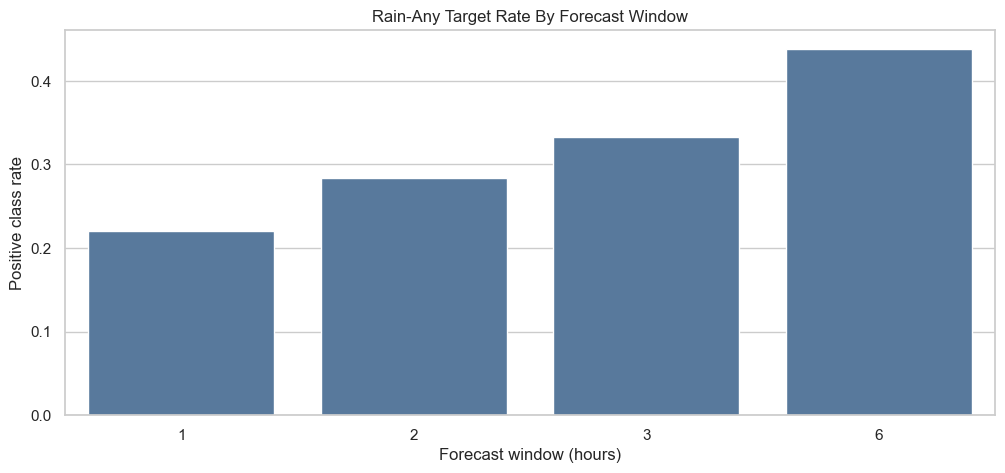

In [6]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": len(df),
        "rain_rows": int(df[f"rain_any_next_{horizon}h"].sum()),
        "rain_rate": float(df[f"rain_any_next_{horizon}h"].mean()),
    }
    for horizon in HORIZONS
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("Rain-Any Target Rate By Forecast Window")
plt.xlabel("Forecast window (hours)")
plt.ylabel("Positive class rate")
plt.show()

## 6. Chronological Split

In [7]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    out = data.copy()
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split").size().rename("rows").reset_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_train = train_df[FEATURE_COLUMNS].astype("float32")
x_validation = validation_df[FEATURE_COLUMNS].astype("float32")
x_test = test_df[FEATURE_COLUMNS].astype("float32")

Train before: 2025-01-18 05:00:00
Validation before: 2025-10-19 01:00:00


,split,rows
0,test,367960
1,train,1717576
2,validation,368032


## 7. Evaluation Helpers

In [8]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": "neighbor_grid",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_recommended_threshold(threshold_results):
    rows = []
    for horizon, threshold in RECOMMENDED_PROBABILITY_THRESHOLDS.items():
        model_name = MODEL_PLAN[horizon]
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == model_name)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train Final 4 Models

In [9]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []

for horizon in HORIZONS:
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...")

    y_train = train_df[target].astype("int8")
    y_validation = validation_df[target].astype("int8")
    y_test = test_df[target].astype("int8")

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_validation, y_validation)],
            eval_metric="binary_logloss",
        )
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        )
        model.fit(x_train, y_train)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split.to_numpy(), probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)
recommended_threshold_metrics = metrics_at_recommended_threshold(all_threshold_results)
feature_importance = pd.DataFrame(feature_importance_rows)

display(all_metrics.sort_values(["horizon_h", "split"]))
display(best_by_f1[best_by_f1["split"] == "test"].sort_values("horizon_h"))
display(recommended_threshold_metrics[recommended_threshold_metrics["split"] == "test"].sort_values("horizon_h"))

Training lightgbm for rain_any_next_1h...
[LightGBM] [Info] Number of positive: 382511, number of negative: 1335065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.615973 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11064
[LightGBM] [Info] Number of data points in the train set: 1717576, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222704 -> initscore=-1.249978
[LightGBM] [Info] Start training from score -1.249978
Training lightgbm for rain_any_next_2h...
[LightGBM] [Info] Number of positive: 487195, number of negative: 1230381
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.635873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11064
[LightGBM] [Info] Number of data points in the train set: 1717576, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.

,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
0,lightgbm,neighbor_grid,1,validation,368032,0.2687,0.9148,0.8131,0.1256
3,lightgbm,neighbor_grid,2,test,367960,0.2184,0.9123,0.7669,0.0993
2,lightgbm,neighbor_grid,2,validation,368032,0.3495,0.8950,0.8300,0.1382
5,hist_gradient_boosting,neighbor_grid,3,test,367960,0.2632,0.9024,0.7815,0.1085
4,hist_gradient_boosting,neighbor_grid,3,validation,368032,0.4111,0.8863,0.8485,0.1350
7,hist_gradient_boosting,neighbor_grid,6,test,367960,0.3644,0.8924,0.8273,0.1295
6,hist_gradient_boosting,neighbor_grid,6,validation,368032,0.5389,0.8811,0.8932,0.1407


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
27,0.6000,0.1760,0.8967,0.6679,0.7241,0.6949,286701,21511,16484,43264,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
59,0.5000,0.2480,0.8572,0.6524,0.7407,0.6937,255887,31718,20834,59521,lightgbm,neighbor_grid,2,test,367960,0.2184,0.9123,0.7669,0.0993
89,0.3000,0.2960,0.8365,0.6683,0.7518,0.7076,234988,36136,24039,72797,hist_gradient_boosting,neighbor_grid,3,test,367960,0.2632,0.9024,0.7815,0.1085
123,0.3000,0.4241,0.8037,0.6982,0.8126,0.7511,186765,47097,25129,108969,hist_gradient_boosting,neighbor_grid,6,test,367960,0.3644,0.8924,0.8273,0.1295


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,0.6000,0.1760,0.8967,0.6679,0.7241,0.6949,286701,21511,16484,43264,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
3,0.5000,0.2480,0.8572,0.6524,0.7407,0.6937,255887,31718,20834,59521,lightgbm,neighbor_grid,2,test,367960,0.2184,0.9123,0.7669,0.0993
5,0.3000,0.2960,0.8365,0.6683,0.7518,0.7076,234988,36136,24039,72797,hist_gradient_boosting,neighbor_grid,3,test,367960,0.2632,0.9024,0.7815,0.1085
7,0.3000,0.4241,0.8037,0.6982,0.8126,0.7511,186765,47097,25129,108969,hist_gradient_boosting,neighbor_grid,6,test,367960,0.3644,0.8924,0.8273,0.1295


## 9. Results Charts

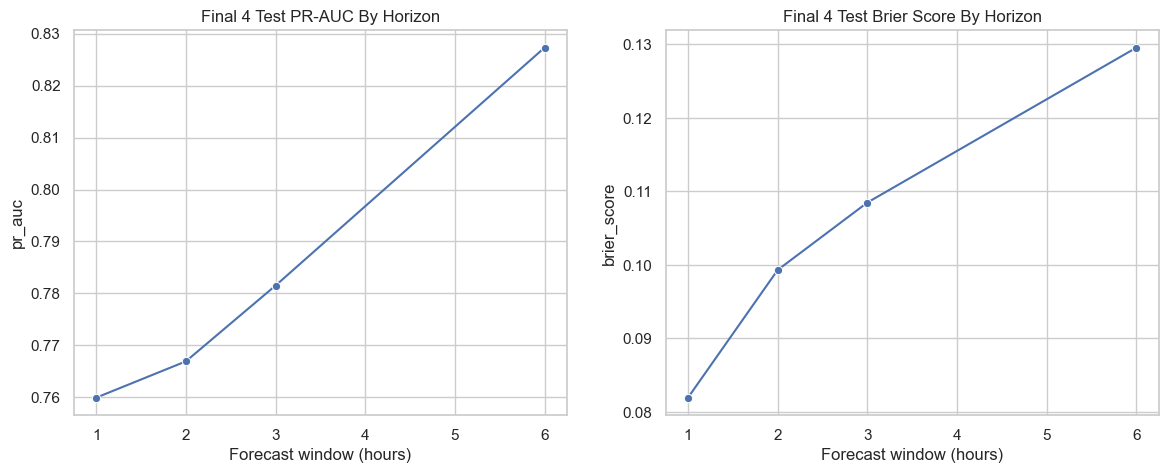

,model,horizon_h,feature,importance,is_neighbor_feature
11,lightgbm,1,pressure_msl_change_6h,1578.0000,False
8,lightgbm,1,wind_direction_10m,1571.0000,False
10,lightgbm,1,pressure_msl_change_3h,1481.0000,False
29,lightgbm,1,hour_cos,1325.0000,False
50,lightgbm,1,neighbor_dew_point_2m_mean,1209.0000,True
28,lightgbm,1,hour_sin,1183.0000,False
30,lightgbm,1,month_sin,1072.0000,False
49,lightgbm,1,neighbor_temperature_2m_mean,933.0000,True
47,lightgbm,1,neighbor_pressure_msl_min,909.0000,True
46,lightgbm,1,neighbor_pressure_msl_mean,862.0000,True


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="pr_auc", marker="o", ax=axes[0])
axes[0].set_title("Final 4 Test PR-AUC By Horizon")
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="brier_score", marker="o", ax=axes[1])
axes[1].set_title("Final 4 Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.show()

if not feature_importance.empty:
    top_importance = feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False]).groupby("horizon_h").head(20)
    display(top_importance)

## 10. Save Final Models And Results

In [11]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = RECOMMENDED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / f"om_bkk_rain_any_next_{horizon}h_neighbor_grid_{model_name}_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "final_4_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "final_4_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "final_4_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "final_4_best_thresholds_by_f1.csv", index=False)
recommended_threshold_metrics.to_csv(MODEL_DIR / "final_4_recommended_threshold_metrics.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "final_4_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "target_type": "rain_any_within_next_n_hours",
    "model_plan": MODEL_PLAN,
    "recommended_probability_thresholds": RECOMMENDED_PROBABILITY_THRESHOLDS,
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "recommended_threshold_metrics": recommended_threshold_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "final_4_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved final 4 models and result CSVs to {MODEL_DIR}")

Saved final 4 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_final_4_neighbor_models
